# L1.9 — Conflict resolution

**Level 1 · Core · 60 minutes**

**Goal.** You can calculate an avoidance command from a conflict.

**Check at the end.** You can name a condition where `MVP` and `VO` give a different answer.

> Level 1 uses no simulation loop. You call each module directly.
>
> The results for `VO` in this library are **provisional**. The implementation is our own.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The contract

```python
class ConflictResolver:
    def resolve(own, intruders, rpz, preferred=None) -> MotionCommand: ...
```

Four things to note, and each one matters later:

1. `intruders` is a **sequence**. A resolver receives the whole conflicting set at once, not one
   intruder at a time. How it combines them is part of the algorithm.
2. It returns a `MotionCommand`, so its output is the same currency every other module speaks.
3. `preferred` is the velocity the aircraft would rather fly. A resolver may use it or ignore it.
4. The states it receives are the **perceived** states, never the true ones.

Two resolvers ship. Both take a `margin` (≥ 1) that enlarges the protected zone they clear.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, PURPLE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#9467bd"

from opencdarr import M600, MVP, VO, create_aircraft, create_conflict
from opencdarr.relative import relative_enu, velocity_enu

RPZ = 50.0

own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0)
intr = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=20.0, rpz=RPZ, gs_intr=10.0)

current = velocity_enu(own)
mvp_cmd = MVP(margin=1.05).resolve(own, [intr], RPZ)
vo_cmd = VO(margin=1.05).resolve(own, [intr], RPZ)

print(f"{'':<12}{'v_east':>9}{'v_north':>10}{'trk':>8}{'gs':>8}{'change':>10}")
print(f"{'current':<12}{current[0]:>9.2f}{current[1]:>10.2f}"
      f"{np.degrees(np.arctan2(*current)) % 360:>8.1f}{np.hypot(*current):>8.2f}{'':>10}")
for name, cmd in (("MVP", mvp_cmd), ("VO", vo_cmd)):
    change = np.hypot(cmd.v_east - current[0], cmd.v_north - current[1])
    print(f"{name:<12}{cmd.v_east:>9.2f}{cmd.v_north:>10.2f}{cmd.trk:>8.1f}{cmd.gs:>8.2f}"
          f"{change:>10.2f}")

               v_east   v_north     trk      gs    change
current          0.00     10.00     0.0   10.00          
MVP             -1.59      8.41   349.3    8.56      2.25
VO              -1.31      8.19   350.9    8.30      2.23


## 2. The two algorithms, in one sentence each

**`MVP`** is a potential field. It calculates the smallest velocity change that puts the closest
approach on the edge of the resolution zone, and it **subtracts** that change from the current
velocity. With more than one intruder it **sums** the pairwise changes. It ignores `preferred`,
because it always steers away from where the aircraft is going now.

**`VO`** builds a **cone** in velocity space for each intruder — every velocity that leads into the
protected zone — and picks the nearest velocity outside the union of the cones. It starts from
`preferred` when you give one, and from the current velocity when you do not.

The difference to remember: MVP moves relative to the **current** velocity. VO moves relative to the
**boundary** of a forbidden set.

## 3. Draw the cone, and both answers

The velocity obstacle for one intruder is a cone in velocity space. Its apex sits at the
**intruder's** velocity, its axis points from the ownship to the intruder, and its half-angle is

$$\alpha = \arcsin\!\left(\frac{R_\text{eff}}{|\mathbf{r}|}\right)$$

Any own velocity inside that cone leads into the zone. Any velocity outside it does not.

Build the cone from the geometry yourself. Then draw both commands on it.

In [2]:
def cone_of(own_state, intr_state, rpz_eff: float):
    """The velocity-obstacle cone: (apex, axis unit vector, half-angle [rad])."""
    rel = relative_enu(own_state, intr_state)
    axis = np.array([rel.rx, rel.ry]) / rel.dist
    half = np.arcsin(min(1.0, rpz_eff / rel.dist))
    return np.array(velocity_enu(intr_state)), axis, half


def rotate(v: np.ndarray, angle: float) -> np.ndarray:
    c, s = np.cos(angle), np.sin(angle)
    return np.array([c * v[0] - s * v[1], s * v[0] + c * v[1]])


apex, axis, half = cone_of(own, intr, RPZ * 1.05)
print(f"cone apex (the intruder's velocity)   ({apex[0]:.2f}, {apex[1]:.2f}) m/s")
print(f"half-angle                            {np.degrees(half):.2f} deg")
print(f"current velocity is inside the cone:  "
      f"{np.dot(np.array(current) - apex, axis) > 0 and np.arccos(np.clip(np.dot((np.array(current) - apex) / np.linalg.norm(np.array(current) - apex), axis), -1, 1)) < half}")

cone apex (the intruder's velocity)   (10.00, 0.00) m/s
half-angle                            9.08 deg
current velocity is inside the cone:  True


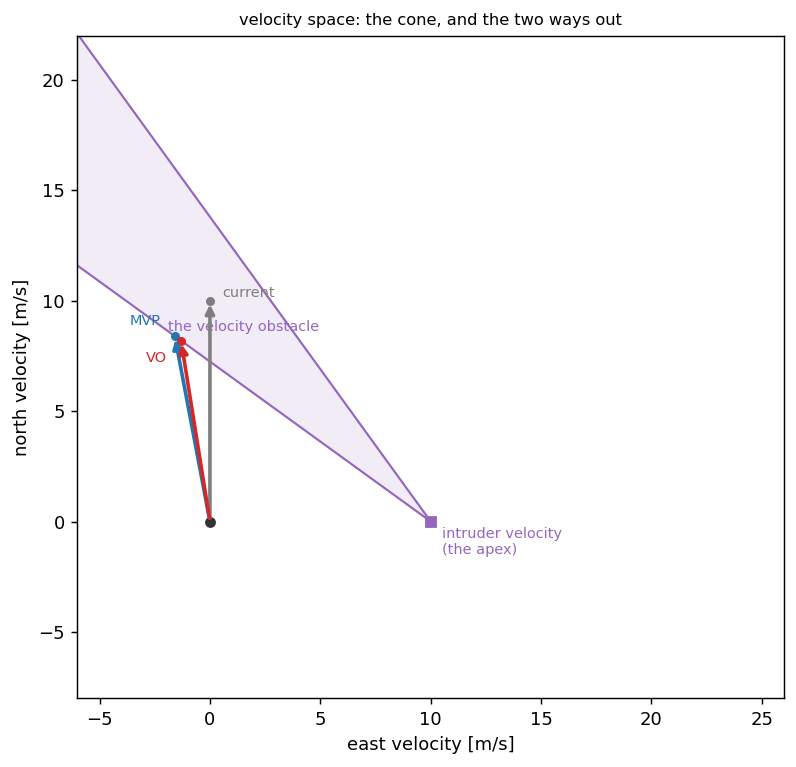

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 6.0))

REACH = 60.0
for sign in (+1, -1):
    edge = apex + rotate(axis, sign * half) * REACH
    ax.plot([apex[0], edge[0]], [apex[1], edge[1]], lw=1.2, color=PURPLE)
wedge = np.array([apex] + [apex + rotate(axis, a) * REACH
                           for a in np.linspace(-half, half, 40)])
ax.fill(wedge[:, 0], wedge[:, 1], color=PURPLE, alpha=0.12, lw=0)
ax.annotate("the velocity obstacle", apex + axis * 12, fontsize=8, color=PURPLE,
            ha="center", va="bottom")

for vec, colour, label, off in ((np.array(current), GREY, "current", (7, 2)),
                                (np.array([mvp_cmd.v_east, mvp_cmd.v_north]), BLUE, "MVP", (-8, 6)),
                                (np.array([vo_cmd.v_east, vo_cmd.v_north]), RED, "VO", (-8, -12))):
    ax.annotate("", vec, (0, 0), arrowprops=dict(arrowstyle="-|>", color=colour, lw=2.0))
    ax.plot(*vec, marker="o", ms=4, color=colour)
    ax.annotate(label, vec, off, textcoords="offset points", fontsize=8, color=colour,
                ha="right" if off[0] < 0 else "left")

ax.plot(*apex, marker="s", ms=6, color=PURPLE)
ax.annotate("intruder velocity\n(the apex)", apex, (6, -18), textcoords="offset points",
            fontsize=8, color=PURPLE)
ax.plot(0, 0, marker="o", ms=5, color="0.2")
ax.set_aspect("equal")
ax.set_xlim(-6, 26)
ax.set_ylim(-8, 22)
ax.set_xlabel("east velocity [m/s]")
ax.set_ylabel("north velocity [m/s]")
ax.set_title("velocity space: the cone, and the two ways out", fontsize=9)
fig.tight_layout()

## 4. What the margin does

`margin` enlarges the zone the resolver clears. `margin=1.0` clears exactly to `rpz`.
`margin=1.05` clears to 52.5 m, so the aircraft keeps a buffer.

A larger margin costs more manoeuvre. Sweep it and read the size of the velocity change.

In [4]:
print(f"{'margin':>8}{'zone [m]':>11}{'MVP change':>14}{'MVP trk':>10}{'VO change':>13}{'VO trk':>9}")
for margin in (1.0, 1.05, 1.2, 1.5, 2.0):
    m = MVP(margin=margin).resolve(own, [intr], RPZ)
    v = VO(margin=margin).resolve(own, [intr], RPZ)
    dm = np.hypot(m.v_east - current[0], m.v_north - current[1])
    dv = np.hypot(v.v_east - current[0], v.v_north - current[1])
    print(f"{margin:>8.2f}{RPZ * margin:>11.1f}{dm:>14.2f}{m.trk:>10.1f}{dv:>13.2f}{v.trk:>9.1f}")

  margin   zone [m]    MVP change   MVP trk    VO change   VO trk
    1.00       50.0          2.14     349.9         2.12    351.4
    1.05       52.5          2.25     349.3         2.23    350.9
    1.20       60.0          2.59     347.4         2.55    349.6
    1.50       75.0          3.27     343.3         3.19    347.0
    2.00      100.0          4.45     335.3         4.25    342.5


## 5. The earlier you act, the less you do

The size of the manoeuvre is set by the geometry, not by the algorithm. To move the closest approach
out to the zone you need a sideways speed of about $R_\text{eff}/t_\text{CPA}$, so the cost falls as
the time to the conflict grows.

This is why `t_lookahead` matters as much as the resolver. A long lookahead buys small manoeuvres. A
short one forces large ones, and a large one may be outside the envelope.

In [5]:
print(f"{'tlos [s]':>10}{'range [m]':>12}{'cone half-angle':>18}{'MVP change':>13}{'VO change':>12}")
for tlos in (15.0, 20.0, 30.0, 60.0, 120.0):
    other = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=tlos, rpz=RPZ,
                            gs_intr=10.0)
    m = MVP(margin=1.05).resolve(own, [other], RPZ)
    v = VO(margin=1.05).resolve(own, [other], RPZ)
    _, _, half_i = cone_of(own, other, RPZ * 1.05)
    print(f"{tlos:>10.0f}{relative_enu(own, other).dist:>12.0f}{np.degrees(half_i):>16.2f} deg"
          f"{np.hypot(m.v_east - current[0], m.v_north - current[1]):>13.2f}"
          f"{np.hypot(v.v_east - current[0], v.v_north - current[1]):>12.2f}")

  tlos [s]   range [m]   cone half-angle   MVP change   VO change
        15         262           11.55 deg         2.89        2.83
        20         333            9.08 deg         2.25        2.23
        30         474            6.36 deg         1.57        1.57
        60         899            3.35 deg         0.83        0.83
       120        1747            1.72 deg         0.42        0.42


## 6. Where the two disagree

Sweep the crossing angle and read both answers. A shallow crossing and a head-on meeting are the
two geometries that separate them: MVP always pushes away from the current velocity, and VO takes
the shortest step to the edge of the cone, which can be a **speed** change rather than a turn.

In [6]:
angles = [10.0, 30.0, 60.0, 90.0, 120.0, 150.0, 175.0]
rows = []
for dpsi in angles:
    other = create_conflict(own, intr_id="INT", dpsi=dpsi, dcpa=0.0, tlos=20.0, rpz=RPZ,
                            gs_intr=10.0)
    m = MVP(margin=1.05).resolve(own, [other], RPZ)
    v = VO(margin=1.05).resolve(own, [other], RPZ)
    rows.append((dpsi,
                 np.hypot(m.v_east - current[0], m.v_north - current[1]), m.trk, m.gs,
                 np.hypot(v.v_east - current[0], v.v_north - current[1]), v.trk, v.gs))

print(f"{'dpsi':>6}{'MVP change':>12}{'trk':>8}{'gs':>7}{'VO change':>12}{'trk':>8}{'gs':>7}")
for dpsi, dm, mt, mg, dv, vt, vg in rows:
    print(f"{dpsi:>6.0f}{dm:>12.2f}{mt:>8.1f}{mg:>7.2f}{dv:>12.2f}{vt:>8.1f}{vg:>7.2f}")

  dpsi  MVP change     trk     gs   VO change     trk     gs
    10        1.37   359.2   8.64        1.08     3.7   9.12
    30        1.88   356.6   8.20        1.77     1.1   8.24
    60        2.14   352.5   8.21        2.10   355.4   8.03
    90        2.25   349.3   8.56        2.23   350.9   8.30
   120        2.31   347.3   9.07        2.29   348.1   8.79
   150        2.34   346.5   9.66        2.32   346.7   9.38
   175        2.34   346.7  10.17        2.33   346.5   9.90


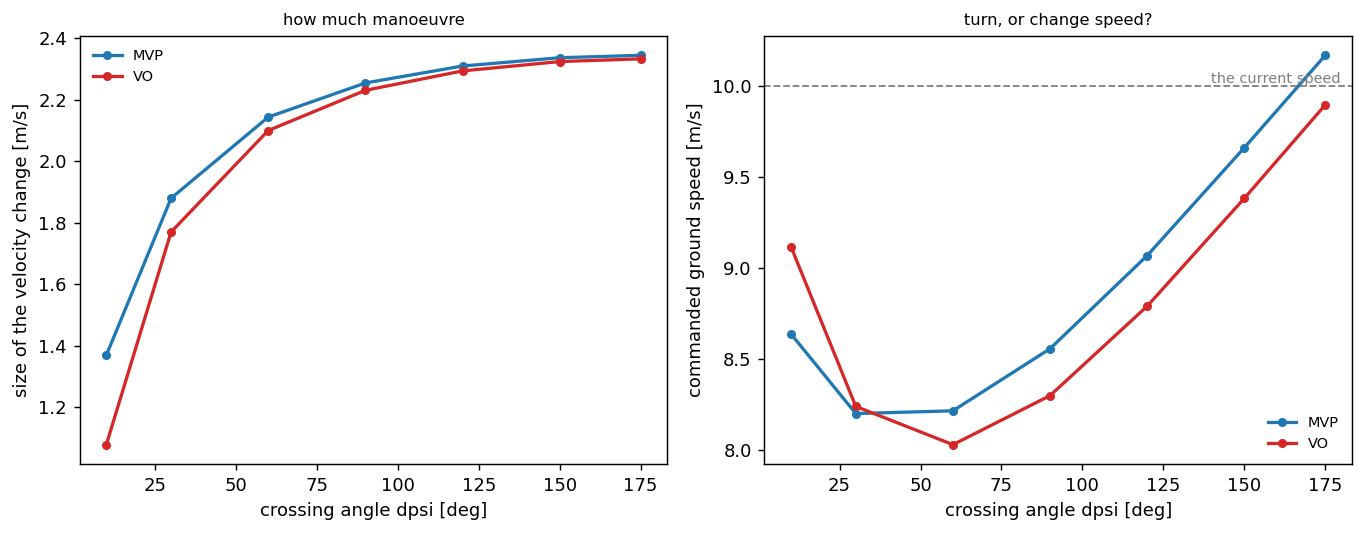

In [7]:
fig, (ax_d, ax_g) = plt.subplots(1, 2, figsize=(10.6, 4.2))
xs = [r[0] for r in rows]
ax_d.plot(xs, [r[1] for r in rows], marker="o", ms=4, lw=1.8, color=BLUE, label="MVP")
ax_d.plot(xs, [r[4] for r in rows], marker="o", ms=4, lw=1.8, color=RED, label="VO")
ax_d.set_ylabel("size of the velocity change [m/s]")
ax_d.set_title("how much manoeuvre", fontsize=9)

ax_g.plot(xs, [r[3] for r in rows], marker="o", ms=4, lw=1.8, color=BLUE, label="MVP")
ax_g.plot(xs, [r[6] for r in rows], marker="o", ms=4, lw=1.8, color=RED, label="VO")
ax_g.axhline(own.gs, ls="--", lw=1.0, color=GREY)
ax_g.annotate("the current speed", (0.98, own.gs), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color=GREY)
ax_g.set_ylabel("commanded ground speed [m/s]")
ax_g.set_title("turn, or change speed?", fontsize=9)

for ax in (ax_d, ax_g):
    ax.set_xlabel("crossing angle dpsi [deg]")
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## 7. More than one intruder

A resolver receives the whole set. The two combine it differently:

- `MVP` sums the pairwise changes. Two intruders that push the same way give a larger manoeuvre than
  either alone.
- `VO` takes the **union** of the cones and leaves all of them at once.

Give both a pair of intruders and compare.

In [8]:
left = create_conflict(own, intr_id="LEFT", dpsi=90.0, dcpa=0.0, tlos=20.0, rpz=RPZ, gs_intr=10.0)
right = create_conflict(own, intr_id="RIGHT", dpsi=270.0, dcpa=0.0, tlos=26.0, rpz=RPZ,
                        gs_intr=10.0)

print(f"{'intruders':<22}{'MVP trk':>10}{'MVP gs':>9}{'VO trk':>10}{'VO gs':>9}")
for label, group in (("LEFT alone", [left]), ("RIGHT alone", [right]),
                     ("both together", [left, right])):
    m = MVP(margin=1.05).resolve(own, group, RPZ)
    v = VO(margin=1.05).resolve(own, group, RPZ)
    print(f"{label:<22}{m.trk:>10.1f}{m.gs:>9.2f}{v.trk:>10.1f}{v.gs:>9.2f}")

intruders                MVP trk   MVP gs    VO trk    VO gs
LEFT alone                 349.3     8.56     350.9     8.30
RIGHT alone                353.6    11.34       7.2     8.66
both together              343.5    10.08     357.4     7.50


## 8. The preferred velocity

`preferred` says "this is where I would rather go". `VO` starts its search from it. `MVP` ignores it.

This is how a resolver can be told about a mission: an aircraft that wants to reach a waypoint has a
preferred direction that is not its current one.

In [9]:
want_east = (10.0, 0.0)          # "I would rather be going east"

print(f"{'resolver':<10}{'preferred':>14}{'trk':>9}{'gs':>8}")
for name, resolver in (("MVP", MVP(margin=1.05)), ("VO", VO(margin=1.05))):
    for label, pref in (("none", None), ("east", want_east)):
        cmd = resolver.resolve(own, [intr], RPZ, preferred=pref)
        print(f"{name:<10}{label:>14}{cmd.trk:>9.1f}{cmd.gs:>8.2f}")

resolver       preferred      trk      gs
MVP                 none    349.3    8.56
MVP                 east    349.3    8.56
VO                  none    350.9    8.30
VO                  east     90.0   10.00


## Do it yourself

1. Set `dcpa=40.0` instead of 0. Compare the size of both manoeuvres.
2. Give `MVP` three intruders that all push the same way. Check that the change adds up.
3. Give `VO` a `preferred` that is already outside the cone. Check that it returns it unchanged.
4. Increase `gs_intr` to 18 m/s and repeat section 5.

## Check

1. MVP moves relative to the current velocity. VO moves relative to the edge of a forbidden set.
   Name a geometry where the two give a different answer.
2. What does `margin` cost, and what does it buy?
3. Why does a resolver receive a sequence of intruders rather than one?

## Next

`L1.10 — Recovery`. The aircraft is avoiding. Next you decide when it can stop.